In [14]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv('datasetw.csv')
df.shape

(120, 63)

In [16]:
df['label'].value_counts()

label
gait_slow      40
gait_normal    40
gait_fast      40
Name: count, dtype: int64

In [17]:
# Implementación de Random Forest desde cero con numpy

class DecisionTree:
    """Árbol de decisión para clasificación implementado desde cero"""
    
    def __init__(self, max_depth=10, min_samples_split=2, n_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.tree = None
    
    def fit(self, X, y):
        """Entrena el árbol de decisión"""
        self.n_features = X.shape[1] if not self.n_features else min(self.n_features, X.shape[1])
        self.tree = self._grow_tree(X, y)
        return self
    
    def _grow_tree(self, X, y, depth=0):
        """Construye el árbol recursivamente"""
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # Criterios de parada
        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._most_common_label(y)
            return {'leaf': True, 'value': leaf_value}
        
        # Selecciona features aleatorias
        feat_idxs = np.random.choice(n_features, self.n_features, replace=False)
        
        # Encuentra el mejor split
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)
        
        # Divide los datos
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        
        # Construye subárboles
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        
        return {
            'leaf': False,
            'feature': best_feat,
            'threshold': best_thresh,
            'left': left,
            'right': right
        }
    
    def _best_split(self, X, y, feat_idxs):
        """Encuentra el mejor split usando Gini impurity"""
        best_gain = -1
        split_idx, split_thresh = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        
        return split_idx, split_thresh
    
    def _information_gain(self, y, X_column, threshold):
        """Calcula la ganancia de información"""
        parent_gini = self._gini_impurity(y)
        
        left_idxs = X_column <= threshold
        right_idxs = ~left_idxs
        
        if np.sum(left_idxs) == 0 or np.sum(right_idxs) == 0:
            return 0
        
        n = len(y)
        n_left, n_right = np.sum(left_idxs), np.sum(right_idxs)
        gini_left = self._gini_impurity(y[left_idxs])
        gini_right = self._gini_impurity(y[right_idxs])
        
        child_gini = (n_left / n) * gini_left + (n_right / n) * gini_right
        
        return parent_gini - child_gini
    
    def _gini_impurity(self, y):
        """Calcula el índice de Gini"""
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def _most_common_label(self, y):
        """Retorna la etiqueta más común"""
        unique, counts = np.unique(y, return_counts=True)
        return unique[np.argmax(counts)]
    
    def predict(self, X):
        """Predice las etiquetas para X"""
        return np.array([self._traverse_tree(x, self.tree) for x in X])
    
    def _traverse_tree(self, x, node):
        """Atraviesa el árbol para hacer una predicción"""
        if node['leaf']:
            return node['value']
        
        if x[node['feature']] <= node['threshold']:
            return self._traverse_tree(x, node['left'])
        return self._traverse_tree(x, node['right'])

In [18]:
class RandomForest:
    """Random Forest implementado desde cero con numpy"""
    
    def __init__(self, n_trees=100, max_depth=10, min_samples_split=2, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees = []
    
    def fit(self, X, y):
        """Entrena el bosque de árboles"""
        self.trees = []
        
        for _ in range(self.n_trees):
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )
            
            # Bootstrap sampling
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # Entrena el árbol
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
        
        return self
    
    def _bootstrap_sample(self, X, y):
        """Crea una muestra bootstrap"""
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]
    
    def predict(self, X):
        """Predice usando votación mayoritaria"""
        # Obtiene predicciones de todos los árboles
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Votación mayoritaria
        predictions = []
        for i in range(X.shape[0]):
            unique, counts = np.unique(tree_preds[:, i], return_counts=True)
            predictions.append(unique[np.argmax(counts)])
        
        return np.array(predictions)

In [19]:
def k_fold_cross_validation(X, y, k=5, n_trees=100, max_depth=10, min_samples_split=2, n_features=None):
    """
    Implementa K-Fold Cross Validation desde cero
    
    Parámetros:
    -----------
    X : array-like
        Características del dataset
    y : array-like
        Etiquetas del dataset
    k : int
        Número de folds (default=5)
    n_trees : int
        Número de árboles en el Random Forest
    max_depth : int
        Profundidad máxima de cada árbol
    min_samples_split : int
        Mínimo de muestras para dividir un nodo
    n_features : int
        Número de features a considerar en cada split
    
    Retorna:
    --------
    dict con métricas de validación
    """
    
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    # Divide los índices en k folds
    fold_size = n_samples // k
    folds = []
    
    for i in range(k):
        start = i * fold_size
        end = start + fold_size if i < k - 1 else n_samples
        folds.append(indices[start:end])
    
    # Almacena resultados
    fold_accuracies = []
    fold_predictions = []
    fold_true_labels = []
    
    print(f"Iniciando {k}-Fold Cross Validation con Random Forest ({n_trees} árboles)...\n")
    
    for fold_idx in range(k):
        print(f"Fold {fold_idx + 1}/{k}:")
        
        # Divide en train y test
        test_indices = folds[fold_idx]
        train_indices = np.concatenate([folds[i] for i in range(k) if i != fold_idx])
        
        X_train, X_test = X[train_indices], X[test_indices]
        y_train, y_test = y[train_indices], y[test_indices]
        
        # Entrena el modelo
        rf = RandomForest(
            n_trees=n_trees,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            n_features=n_features
        )
        
        rf.fit(X_train, y_train)
        
        # Predice
        y_pred = rf.predict(X_test)
        
        # Calcula accuracy
        accuracy = np.mean(y_pred == y_test)
        fold_accuracies.append(accuracy)
        
        fold_predictions.append(y_pred)
        fold_true_labels.append(y_test)
        
        print(f"  Tamaño train: {len(X_train)}, Tamaño test: {len(X_test)}")
        print(f"  Accuracy: {accuracy:.4f}\n")
    
    # Calcula métricas globales
    all_predictions = np.concatenate(fold_predictions)
    all_true_labels = np.concatenate(fold_true_labels)
    
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    
    print("=" * 50)
    print("RESULTADOS FINALES:")
    print(f"Accuracy por fold: {[f'{acc:.4f}' for acc in fold_accuracies]}")
    print(f"Accuracy promedio: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
    print("=" * 50)
    
    return {
        'fold_accuracies': fold_accuracies,
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'all_predictions': all_predictions,
        'all_true_labels': all_true_labels
    }

In [20]:
# Preparar los datos
X = df.drop('label', axis=1).values
y = df['label'].values

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Clases: {np.unique(y)}")

Shape de X: (120, 62)
Shape de y: (120,)
Clases: ['gait_fast' 'gait_normal' 'gait_slow']


In [21]:
# Ejecutar K-Fold Cross Validation con Random Forest
np.random.seed(42)  # Para reproducibilidad

# Parámetros del modelo
n_features_sqrt = int(np.sqrt(X.shape[1]))  # Regla común: sqrt(n_features)

results = k_fold_cross_validation(
    X=X, 
    y=y, 
    k=5,
    n_trees=50,  # Reducido para que sea más rápido
    max_depth=10,
    min_samples_split=2,
    n_features=n_features_sqrt
)

Iniciando 5-Fold Cross Validation con Random Forest (50 árboles)...

Fold 1/5:
  Tamaño train: 96, Tamaño test: 24
  Accuracy: 0.6667

Fold 2/5:
  Tamaño train: 96, Tamaño test: 24
  Accuracy: 0.8333

Fold 3/5:
  Tamaño train: 96, Tamaño test: 24
  Accuracy: 0.8333

Fold 4/5:
  Tamaño train: 96, Tamaño test: 24
  Accuracy: 0.5833

Fold 5/5:
  Tamaño train: 96, Tamaño test: 24
  Accuracy: 0.7083

RESULTADOS FINALES:
Accuracy por fold: ['0.6667', '0.8333', '0.8333', '0.5833', '0.7083']
Accuracy promedio: 0.7250 (+/- 0.0972)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Función para crear matriz de confusión
def create_confusion_matrix(y_true, y_pred, class_labels):
    """Crea una matriz de confusión para clasificación multiclase"""
    n_classes = len(class_labels)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    for i, true_label in enumerate(class_labels):
        for j, pred_label in enumerate(class_labels):
            cm[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    
    return cm

def plot_confusion_matrix(cm, class_labels, title='Matriz de Confusión'):
    """Visualiza la matriz de confusión con matplotlib"""
    
    plt.figure(figsize=(10, 8))
    
    # Crear heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Número de muestras'},
                linewidths=0.5,
                linecolor='gray')
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Verdadera', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # También imprimir en formato texto
    print("\n" + "=" * 80)
    print("MATRIZ DE CONFUSIÓN MULTICLASE (Formato Texto)")
    print("=" * 80)
    print("\nFilas = Verdadero, Columnas = Predicho\n")
    
    # Encabezado
    header = "Verdadero\\Predicho".ljust(20)
    for label in class_labels:
        header += f"{label[:15]:>15}"
    print(header)
    print("-" * len(header))
    
    # Filas
    for i, true_label in enumerate(class_labels):
        row = f"{true_label[:18]}".ljust(20)
        for j in range(len(class_labels)):
            row += f"{cm[i, j]:>15}"
        print(row)
    
    print("=" * 80)

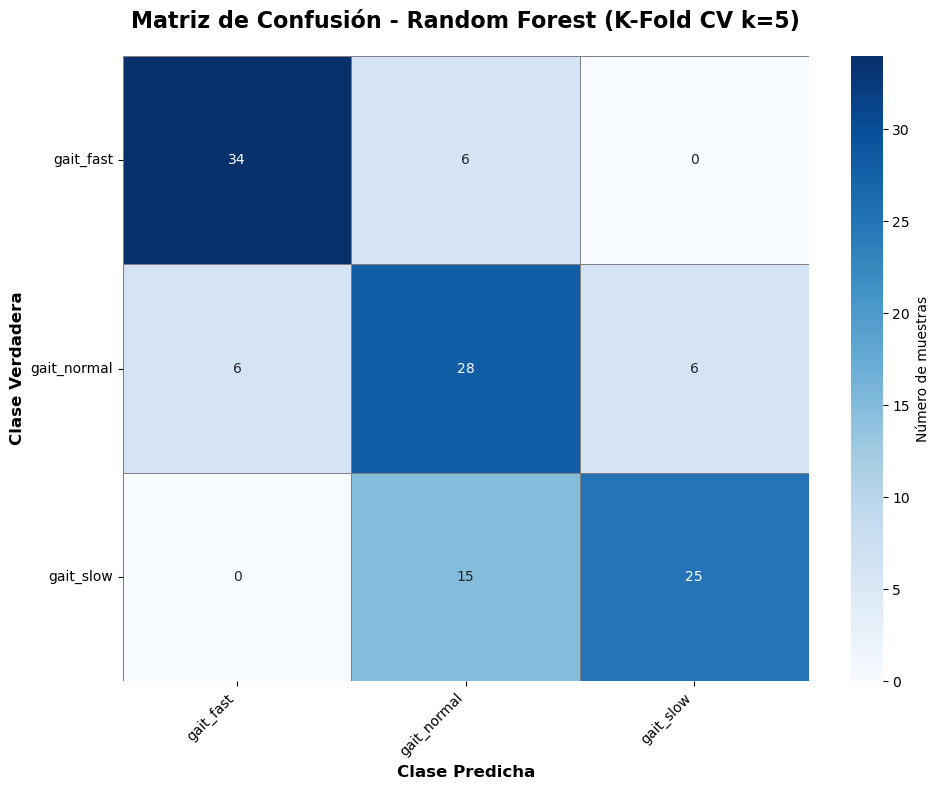


MATRIZ DE CONFUSIÓN MULTICLASE (Formato Texto)

Filas = Verdadero, Columnas = Predicho

Verdadero\Predicho        gait_fast    gait_normal      gait_slow
-----------------------------------------------------------------
gait_fast                        34              6              0
gait_normal                       6             28              6
gait_slow                         0             15             25


In [23]:
# Generar y mostrar matriz de confusión
class_labels = np.unique(y)
cm = create_confusion_matrix(
    y_true=results['all_true_labels'],
    y_pred=results['all_predictions'],
    class_labels=class_labels
)

plot_confusion_matrix(cm, class_labels, 
                     title='Matriz de Confusión - Random Forest (K-Fold CV k=5)')

In [24]:
# Funciones para calcular métricas por clase
def calculate_metrics_per_class(y_true, y_pred, class_labels):
    """
    Calcula métricas de desempeño para cada clase
    
    Métricas calculadas:
    - Sensitivity (Recall/TPR): TP / (TP + FN)
    - Specificity (TNR): TN / (TN + FP)
    - Precision (PPV): TP / (TP + FP)
    - F1-Score: 2 * (Precision * Recall) / (Precision + Recall)
    - Balanced Accuracy: (Sensitivity + Specificity) / 2
    """
    
    metrics = {}
    
    for label in class_labels:
        # Convertir a problema binario (one-vs-rest)
        y_true_binary = (y_true == label).astype(int)
        y_pred_binary = (y_pred == label).astype(int)
        
        # Calcular TP, TN, FP, FN
        TP = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
        TN = np.sum((y_true_binary == 0) & (y_pred_binary == 0))
        FP = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
        FN = np.sum((y_true_binary == 1) & (y_pred_binary == 0))
        
        # Calcular métricas
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        
        if precision + sensitivity > 0:
            f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
        else:
            f1_score = 0
        
        balanced_accuracy = (sensitivity + specificity) / 2
        
        metrics[label] = {
            'TP': TP,
            'TN': TN,
            'FP': FP,
            'FN': FN,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Precision': precision,
            'F1-Score': f1_score,
            'Balanced Accuracy': balanced_accuracy
        }
    
    return metrics


def print_metrics_table(metrics):
    """Imprime las métricas en formato de tabla"""
    
    # Crear DataFrame para mejor visualización
    data = []
    for label, label_metrics in metrics.items():
        data.append({
            'Clase': label,
            'Sensitivity/Recall': label_metrics['Sensitivity'],
            'Specificity': label_metrics['Specificity'],
            'Precision': label_metrics['Precision'],
            'F1-Score': label_metrics['F1-Score'],
            'Balanced Accuracy': label_metrics['Balanced Accuracy']
        })
    
    metrics_df = pd.DataFrame(data)
    
    # Calcular promedios macro
    avg_row = {
        'Clase': 'MACRO AVG',
        'Sensitivity/Recall': metrics_df['Sensitivity/Recall'].mean(),
        'Specificity': metrics_df['Specificity'].mean(),
        'Precision': metrics_df['Precision'].mean(),
        'F1-Score': metrics_df['F1-Score'].mean(),
        'Balanced Accuracy': metrics_df['Balanced Accuracy'].mean()
    }
    
    # Agregar fila de promedio
    metrics_df = pd.concat([metrics_df, pd.DataFrame([avg_row])], ignore_index=True)
    
    print("\n" + "=" * 100)
    print("MÉTRICAS DE DESEMPEÑO POR CLASE (K-FOLD CROSS VALIDATION k=5)")
    print("=" * 100)
    print(metrics_df.to_string(index=False))
    print("=" * 100)
    
    return metrics_df

In [25]:
# Calcular y mostrar métricas de desempeño por clase
metrics = calculate_metrics_per_class(
    y_true=results['all_true_labels'],
    y_pred=results['all_predictions'],
    class_labels=class_labels
)

metrics_df = print_metrics_table(metrics)
display(metrics_df)


MÉTRICAS DE DESEMPEÑO POR CLASE (K-FOLD CROSS VALIDATION k=5)
      Clase  Sensitivity/Recall  Specificity  Precision  F1-Score  Balanced Accuracy
  gait_fast               0.850       0.9250   0.850000  0.850000            0.88750
gait_normal               0.700       0.7375   0.571429  0.629213            0.71875
  gait_slow               0.625       0.9250   0.806452  0.704225            0.77500
  MACRO AVG               0.725       0.8625   0.742627  0.727813            0.79375


,Clase,Sensitivity/Recall,Specificity,Precision,F1-Score,Balanced Accuracy
0,gait_fast,0.850,0.9250,0.850000,0.850000,0.88750
1,gait_normal,0.700,0.7375,0.571429,0.629213,0.71875
2,gait_slow,0.625,0.9250,0.806452,0.704225,0.77500
3,MACRO AVG,0.725,0.8625,0.742627,0.727813,0.79375


In [26]:
# Funciones para calcular totales y recall averages
def calculate_total_confusion_values(metrics, class_labels):
    """
    Calcula los valores totales de TP, FN, FP, TN sumando todas las clases
    """
    TP_total = sum([metrics[label]['TP'] for label in class_labels])
    FN_total = sum([metrics[label]['FN'] for label in class_labels])
    FP_total = sum([metrics[label]['FP'] for label in class_labels])
    TN_total = sum([metrics[label]['TN'] for label in class_labels])
    
    return TP_total, FN_total, FP_total, TN_total


def calculate_recall_averages(y_true, y_pred, metrics, class_labels):
    """
    Calcula Recall Macro-Average, Weighted-Average y Micro-Average
    
    - Macro-Average: Promedio simple de los recalls de cada clase
    - Weighted-Average: Promedio ponderado por el número de muestras de cada clase
    - Micro-Average: Calcula globalmente contando todos los TP y FN
    """
    
    # 1. Recall Macro-Average: Promedio simple
    recalls = [metrics[label]['Sensitivity'] for label in class_labels]
    recall_macro = np.mean(recalls)
    
    # 2. Recall Weighted-Average: Promedio ponderado
    class_counts = [np.sum(y_true == label) for label in class_labels]
    total_samples = len(y_true)
    
    recall_weighted = 0
    for label, count in zip(class_labels, class_counts):
        weight = count / total_samples
        recall_weighted += metrics[label]['Sensitivity'] * weight
    
    # 3. Recall Micro-Average: TP_total / (TP_total + FN_total)
    TP_total = sum([metrics[label]['TP'] for label in class_labels])
    FN_total = sum([metrics[label]['FN'] for label in class_labels])
    recall_micro = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0
    
    return recall_macro, recall_weighted, recall_micro

In [30]:
# Mostrar el DataFrame con mejor formato
print("\nDataFrame de métricas:")
display(metrics_df)


DataFrame de métricas:


,Clase,Sensitivity/Recall,Specificity,Precision,F1-Score,Balanced Accuracy
0,gait_fast,0.850,0.9250,0.850000,0.850000,0.88750
1,gait_normal,0.700,0.7375,0.571429,0.629213,0.71875
2,gait_slow,0.625,0.9250,0.806452,0.704225,0.77500
3,MACRO AVG,0.725,0.8625,0.742627,0.727813,0.79375


In [31]:
def calculate_total_confusion_values(metrics, class_labels):
    """
    Calcula los valores totales de TP, FN, FP, TN sumando todas las clases
    """
    TP_total = sum([metrics[label]['TP'] for label in class_labels])
    FN_total = sum([metrics[label]['FN'] for label in class_labels])
    FP_total = sum([metrics[label]['FP'] for label in class_labels])
    TN_total = sum([metrics[label]['TN'] for label in class_labels])
    
    return TP_total, FN_total, FP_total, TN_total

In [32]:
def calculate_recall_averages(y_true, y_pred, metrics, class_labels):
    """
    Calcula Recall Macro-Average, Weighted-Average y Micro-Average
    
    - Macro-Average: Promedio simple de los recalls de cada clase
    - Weighted-Average: Promedio ponderado por el número de muestras de cada clase
    - Micro-Average: Calcula globalmente contando todos los TP y FN
    """
    
    # 1. Recall Macro-Average: Promedio simple
    recalls = [metrics[label]['Sensitivity'] for label in class_labels]
    recall_macro = np.mean(recalls)
    
    # 2. Recall Weighted-Average: Promedio ponderado
    class_counts = [np.sum(y_true == label) for label in class_labels]
    total_samples = len(y_true)
    
    recall_weighted = 0
    for label, count in zip(class_labels, class_counts):
        weight = count / total_samples
        recall_weighted += metrics[label]['Sensitivity'] * weight
    
    # 3. Recall Micro-Average: TP_total / (TP_total + FN_total)
    TP_total = sum([metrics[label]['TP'] for label in class_labels])
    FN_total = sum([metrics[label]['FN'] for label in class_labels])
    recall_micro = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0
    
    return recall_macro, recall_weighted, recall_micro

In [33]:
# Calcular valores totales
TP_total, FN_total, FP_total, TN_total = calculate_total_confusion_values(metrics, class_labels)

# Mostrar resultados
print("\n" + "=" * 80)
print("VALORES TOTALES DE LA MATRIZ DE CONFUSIÓN")
print("=" * 80)
print(f"TP total (True Positives):   {TP_total}")
print(f"FN total (False Negatives):  {FN_total}")
print(f"FP total (False Positives):  {FP_total}")
print(f"TN total (True Negatives):   {TN_total}")
print("=" * 80)


VALORES TOTALES DE LA MATRIZ DE CONFUSIÓN
TP total (True Positives):   87
FN total (False Negatives):  33
FP total (False Positives):  33
TN total (True Negatives):   207


In [34]:
# Calcular los diferentes tipos de Recall
recall_macro, recall_weighted, recall_micro = calculate_recall_averages(
    results['all_true_labels'], 
    results['all_predictions'], 
    metrics, 
    class_labels
)

print("\n" + "=" * 80)
print("RECALL (SENSITIVITY) - DIFERENTES PROMEDIOS")
print("=" * 80)
print(f"Recall Macro-Average:    {recall_macro:.4f}")
print(f"  (Promedio simple de los recalls de cada clase)")
print(f"\nRecall Weighted-Average: {recall_weighted:.4f}")
print(f"  (Promedio ponderado por el número de muestras de cada clase)")
print(f"\nRecall Micro-Average:    {recall_micro:.4f}")
print(f"  (Calculado globalmente: TP_total / (TP_total + FN_total))")
print("=" * 80)


RECALL (SENSITIVITY) - DIFERENTES PROMEDIOS
Recall Macro-Average:    0.7250
  (Promedio simple de los recalls de cada clase)

Recall Weighted-Average: 0.7250
  (Promedio ponderado por el número de muestras de cada clase)

Recall Micro-Average:    0.7250
  (Calculado globalmente: TP_total / (TP_total + FN_total))


In [35]:
# Mostrar recall individual de cada clase para referencia
print("\n" + "=" * 80)
print("RECALL POR CLASE (para referencia)")
print("=" * 80)
for label in class_labels:
    count = np.sum(results['all_true_labels'] == label)
    print(f"{label:15} - Recall: {metrics[label]['Sensitivity']:.4f}  (n={count} muestras)")
print("=" * 80)


RECALL POR CLASE (para referencia)
gait_fast       - Recall: 0.8500  (n=40 muestras)
gait_normal     - Recall: 0.7000  (n=40 muestras)
gait_slow       - Recall: 0.6250  (n=40 muestras)
